In [1]:
import os

In [2]:
dataset_path = "/Users/partha/Developer/ML Project/dataset"
print("Dataset Structure:")
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    
    for file in files[:5]:  # First 5 files
        print(f'{subindent}{file}')
        
    if level > 2:  # Limit depth
        break

Dataset Structure:
dataset/
  .DS_Store
  EuroSAT_RGB/
    .DS_Store
    Forest/
      Forest_864.jpg
      Forest_2917.jpg
      Forest_2903.jpg
      Forest_870.jpg
      Forest_680.jpg
    River/
      River_1456.jpg
      River_1330.jpg
      River_1324.jpg
      River_1442.jpg
      River_2163.jpg
    Highway/
      Highway_1807.jpg
      Highway_180.jpg
      Highway_194.jpg
      Highway_1813.jpg
      Highway_1185.jpg
    AnnualCrop/
      AnnualCrop_1414.jpg
      AnnualCrop_1372.jpg
      AnnualCrop_1366.jpg
      AnnualCrop_2109.jpg
      AnnualCrop_1400.jpg
    SeaLake/
      SeaLake_179.jpg
      SeaLake_145.jpg
      SeaLake_623.jpg
      SeaLake_2852.jpg
      SeaLake_1383.jpg
    HerbaceousVegetation/
      HerbaceousVegetation_2130.jpg
      HerbaceousVegetation_206.jpg
      HerbaceousVegetation_1439.jpg
      HerbaceousVegetation_560.jpg
      HerbaceousVegetation_2656.jpg
    Industrial/
      Industrial_1053.jpg
      Industrial_931.jpg
      Industrial_1735.jpg
  

In [3]:
sample_files = []
for root, dirs, files in os.walk(dataset_path):
    for f in files:
        if f.endswith(('.npy', '.tif', '.jpg', '.png')):
            sample_files.append(os.path.join(root, f))
    if sample_files:
        break

if sample_files:
    sample = sample_files[0]
    print(f"\n Sample file: {sample}")
    if sample.endswith('.npy'):
        data = np.load(sample)
        print(f"   Shape: {data.shape}")
        print(f"   Dtype: {data.dtype}")
        print(f"   Range: [{data.min():.2f}, {data.max():.2f}]")


 Sample file: /Users/partha/Developer/ML Project/dataset/EuroSAT_RGB/Forest/Forest_864.jpg


MS Path:  /Users/partha/Developer/ML Project/dataset/EuroSAT_MS
RGB Path: /Users/partha/Developer/ML Project/dataset/EuroSAT_RGB
Loaded 27000 MS + 27000 RGB images
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total classes: 10
DataLoader ready
Batch size: 8
Total batches: 3375
Batch Shapes
MS Full:    torch.Size([8, 13, 64, 64])
RGB:        torch.Size([8, 3, 64, 64])
Spatial:    torch.Size([8, 4, 64, 64])
Spectral:   torch.Size([8, 13])
Labels:     torch.Size([8])
Classes:    ['AnnualCrop', 'Residential', 'Industrial', 'River', 'Residential', 'Residential', 'PermanentCrop', 'SeaLake']


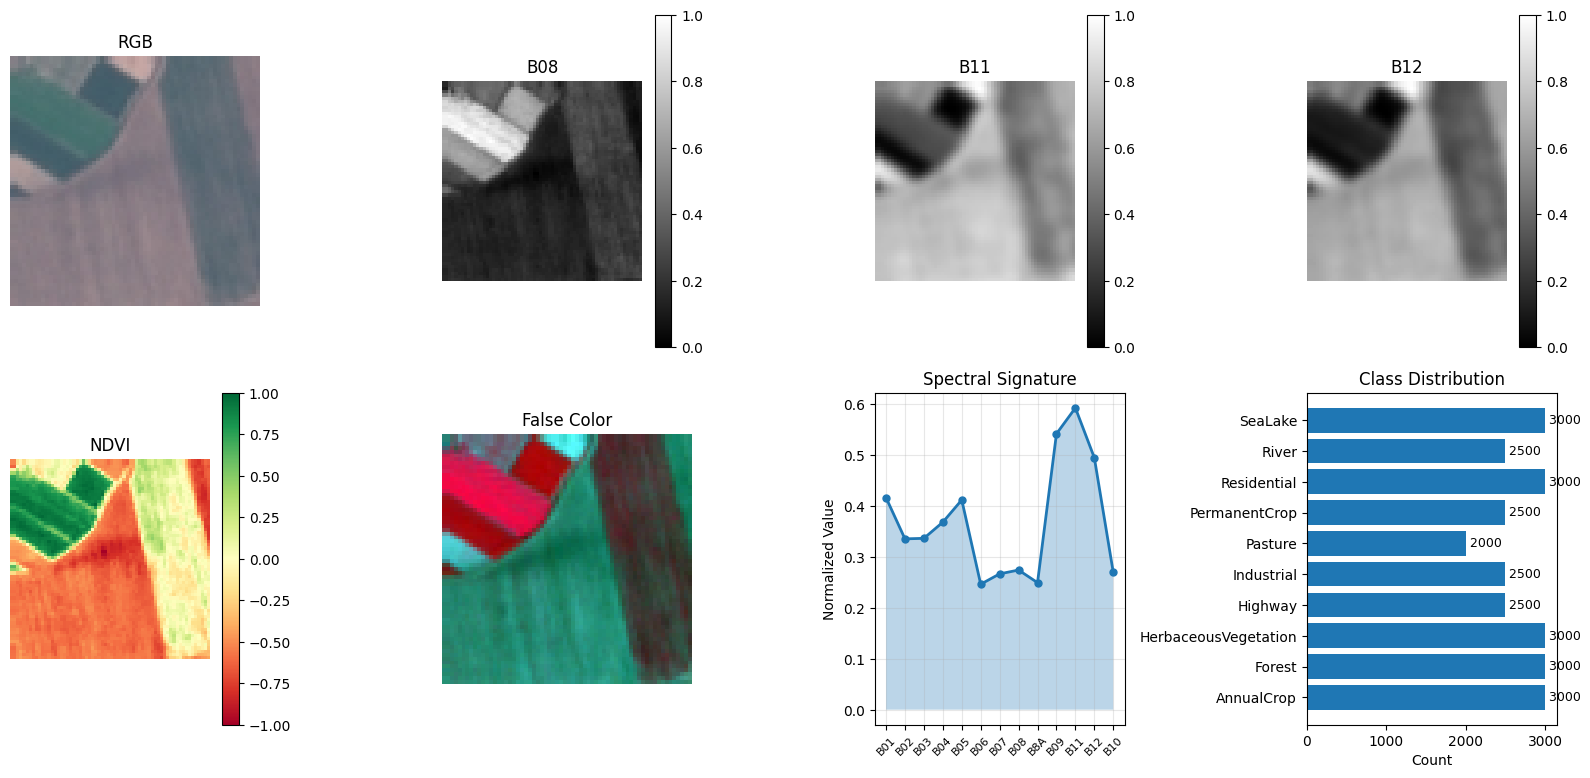

Visualization saved to /Users/partha/Developer/ML Project/eurosat_preprocessing_visualization.png
Sample image class: AnnualCrop
Spectral range: 0.24653105 0.5931212
DATASET SUMMARY
Total samples: 27000
Total classes: 10
AnnualCrop                : 3000
Forest                    : 3000
HerbaceousVegetation      : 3000
Highway                   : 2500
Industrial                : 2500
Pasture                   : 2000
PermanentCrop             : 2500
Residential               : 3000
River                     : 2500
SeaLake                   : 3000
Dataset ready for training


In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from pathlib import Path
import os
from PIL import Image
import rasterio
import warnings
warnings.filterwarnings('ignore')


class EuroSATMSPreprocessor:

    def __init__(self, normalize=True, use_rasterio=True):
        self.normalize = normalize
        self.use_rasterio = use_rasterio

        self.band_names = [
            'B01-Coastal', 'B02-Blue', 'B03-Green', 'B04-Red',
            'B05-VRE1', 'B06-VRE2', 'B07-VRE3', 'B08-NIR',
            'B8A-NarrowNIR', 'B09-WaterVapor', 'B11-SWIR1', 'B12-SWIR2',
            'B10-Cirrus'
        ]

    def load_geotiff(self, file_path):
        try:
            if self.use_rasterio:
                with rasterio.open(file_path) as src:
                    data = src.read()
            else:
                img = Image.open(file_path)
                data = np.array(img)

                if len(data.shape) == 2:
                    data = np.expand_dims(data, axis=0)
                elif data.shape[-1] <= 4 and len(data.shape) == 3:
                    data = np.transpose(data, (2, 0, 1))

        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            return None

        return data.astype(np.float32)

    def normalize_bands(self, ms_data):
        normalized = np.zeros_like(ms_data, dtype=np.float32)

        for band_idx in range(ms_data.shape[0]):
            band = ms_data[band_idx].astype(np.float32)
            band_min = band.min()
            band_max = band.max()

            if band_max > band_min:
                normalized[band_idx] = (band - band_min) / (band_max - band_min)
            else:
                normalized[band_idx] = band

        return normalized

    def extract_rgb(self, ms_data):
        if ms_data.shape[0] >= 4:
            rgb = ms_data[[3, 2, 1]]
            return rgb
        else:
            raise ValueError(f"Need ≥4 bands, got {ms_data.shape[0]}")

    def extract_spatial_4band(self, ms_data):
        if ms_data.shape[0] >= 8:
            spatial = ms_data[[1, 2, 3, 7]]
            return spatial
        else:
            raise ValueError(f"Need ≥8 bands, got {ms_data.shape[0]}")

    def extract_spectral_vector(self, ms_data):
        spectral = ms_data.mean(axis=(1, 2))
        return spectral

    def preprocess(self, file_path):
        ms_data = self.load_geotiff(file_path)
        if ms_data is None:
            return None

        if ms_data.shape[0] > 13:
            ms_data = ms_data[:13]
        elif ms_data.shape[0] < 13:
            pad_width = ((0, 13 - ms_data.shape[0]), (0, 0), (0, 0))
            ms_data = np.pad(ms_data, pad_width, mode='constant', constant_values=0)

        if self.normalize:
            ms_data = self.normalize_bands(ms_data)

        rgb = self.extract_rgb(ms_data)
        spatial = self.extract_spatial_4band(ms_data)
        spectral = self.extract_spectral_vector(ms_data)

        return {
            'ms_full': ms_data,
            'rgb': rgb,
            'spatial': spatial,
            'spectral': spectral,
            'shape': ms_data.shape
        }


class EuroSATRGBPreprocessor:

    def __init__(self, normalize=True):
        self.normalize = normalize

    def load_rgb_image(self, file_path):
        try:
            img = Image.open(file_path)
            data = np.array(img, dtype=np.float32)

            if len(data.shape) == 2:
                data = np.stack([data, data, data], axis=-1)

            return data
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            return None

    def normalize_rgb(self, rgb_data):
        if rgb_data.max() > 1.0:
            rgb_data = rgb_data / 255.0
        return rgb_data

    def preprocess(self, file_path):
        rgb = self.load_rgb_image(file_path)
        if rgb is None:
            return None

        if self.normalize:
            rgb = self.normalize_rgb(rgb)

        rgb = np.transpose(rgb, (2, 0, 1))

        return {
            'rgb': rgb,
            'shape': rgb.shape
        }


class EuroSATDualDataset(Dataset):

    def __init__(self, ms_path, rgb_path, preprocessor_ms=None, preprocessor_rgb=None, split='train'):
        self.ms_path = Path(ms_path)
        self.rgb_path = Path(rgb_path)
        self.split = split

        self.preprocessor_ms = preprocessor_ms or EuroSATMSPreprocessor(normalize=True)
        self.preprocessor_rgb = preprocessor_rgb or EuroSATRGBPreprocessor(normalize=True)

        self.class_names = sorted([d for d in os.listdir(ms_path) if os.path.isdir(os.path.join(ms_path, d))])
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.class_names)}

        self.ms_image_paths = []
        self.rgb_image_paths = []
        self.labels = []

        for class_name in self.class_names:
            ms_class_dir = self.ms_path / class_name
            rgb_class_dir = self.rgb_path / class_name

            if ms_class_dir.exists():
                for ms_file in sorted(ms_class_dir.glob('*.tif')):

                    rgb_file = rgb_class_dir / f"{ms_file.stem}.jpg"

                    # FIX: only keep valid pairs
                    if not rgb_file.exists():
                        continue

                    self.ms_image_paths.append(str(ms_file))
                    self.rgb_image_paths.append(str(rgb_file))
                    self.labels.append(self.class_to_idx[class_name])

        print(f"Loaded {len(self.ms_image_paths)} MS + {len(self.rgb_image_paths)} RGB images")
        print(f"Classes: {self.class_names}")
        print(f"Total classes: {len(self.class_names)}")

    def __len__(self):
        return len(self.ms_image_paths)

    def __getitem__(self, idx):
        ms_path = self.ms_image_paths[idx]
        rgb_path = self.rgb_image_paths[idx]
        label = self.labels[idx]

        ms_data = self.preprocessor_ms.preprocess(ms_path)
        if ms_data is None:
            raise RuntimeError(f"Failed to load MS: {ms_path}")

        rgb_data = self.preprocessor_rgb.preprocess(rgb_path)

        return {
            'ms_full': torch.FloatTensor(ms_data['ms_full']),
            'spatial': torch.FloatTensor(ms_data['spatial']),
            'spectral': torch.FloatTensor(ms_data['spectral']),
            'rgb': torch.FloatTensor(rgb_data['rgb']),
            'label': label,
            'class_name': self.class_names[label],
            'ms_path': ms_path
        }


dataset_root = "/Users/partha/Developer/ML Project/dataset"
ms_path = os.path.join(dataset_root, "EuroSAT_MS")
rgb_path = os.path.join(dataset_root, "EuroSAT_RGB")

print(f"MS Path:  {ms_path}")
print(f"RGB Path: {rgb_path}")

dataset = EuroSATDualDataset(ms_path, rgb_path)

batch_size = 8
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

print("DataLoader ready")
print(f"Batch size: {batch_size}")
print(f"Total batches: {len(train_loader)}")

batch = next(iter(train_loader))

print("Batch Shapes")
print(f"MS Full:    {batch['ms_full'].shape}")
print(f"RGB:        {batch['rgb'].shape}")
print(f"Spatial:    {batch['spatial'].shape}")
print(f"Spectral:   {batch['spectral'].shape}")
print(f"Labels:     {batch['label'].shape}")
print(f"Classes:    {batch['class_name']}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

img_idx = 0

ms_full = batch['ms_full'][img_idx].numpy()
rgb = batch['rgb'][img_idx].numpy()
spectral = batch['spectral'][img_idx].numpy()

ax = axes[0, 0]
rgb_vis = np.transpose(rgb, (1, 2, 0))
rgb_vis = np.clip(rgb_vis, 0, 1)
ax.imshow(rgb_vis)
ax.set_title('RGB')
ax.axis('off')

ax = axes[0, 1]
nir = ms_full[7]
ax.imshow(nir, cmap='gray')
ax.set_title('B08')
ax.axis('off')
plt.colorbar(ax.images[0], ax=ax)

ax = axes[0, 2]
swir1 = ms_full[10]
ax.imshow(swir1, cmap='gray')
ax.set_title('B11')
ax.axis('off')
plt.colorbar(ax.images[0], ax=ax)

ax = axes[0, 3]
swir2 = ms_full[11]
ax.imshow(swir2, cmap='gray')
ax.set_title('B12')
ax.axis('off')
plt.colorbar(ax.images[0], ax=ax)

ax = axes[1, 0]
b08 = ms_full[7]
b04 = ms_full[3]
ndvi = (b08 - b04) / (b08 + b04 + 1e-8)
im = ax.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_title('NDVI')
ax.axis('off')
plt.colorbar(im, ax=ax)

ax = axes[1, 1]
false_color = np.stack([nir, ms_full[3], ms_full[2]], axis=-1)
false_color = np.clip(false_color, 0, 1)
ax.imshow(false_color)
ax.set_title('False Color')
ax.axis('off')

ax = axes[1, 2]
bands_short = ['B01','B02','B03','B04','B05','B06','B07','B08','B8A','B09','B11','B12','B10']
ax.plot(spectral, 'o-', linewidth=2, markersize=5)
ax.fill_between(range(13), spectral, alpha=0.3)
ax.set_xticks(range(13))
ax.set_xticklabels(bands_short, rotation=45, fontsize=8)
ax.set_title('Spectral Signature')
ax.set_ylabel('Normalized Value')
ax.grid(True, alpha=0.3)

ax = axes[1, 3]
class_counts = [sum(1 for l in dataset.labels if l == i) for i in range(len(dataset.class_names))]
ax.barh(dataset.class_names, class_counts)
ax.set_title('Class Distribution')
ax.set_xlabel('Count')

for i, v in enumerate(class_counts):
    ax.text(v, i, f' {v}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/Users/partha/Developer/ML Project/eurosat_preprocessing_visualization.png', dpi=100, bbox_inches='tight')
plt.show()

print("Visualization saved to /Users/partha/Developer/ML Project/eurosat_preprocessing_visualization.png")

print("Sample image class:", batch['class_name'][0])
print("Spectral range:", spectral.min(), spectral.max())

print("DATASET SUMMARY")

print("Total samples:", len(dataset))
print("Total classes:", len(dataset.class_names))

for cls in dataset.class_names:
    count = sum(1 for l in dataset.labels if dataset.class_to_idx[cls] == l)
    print(f"{cls:25} : {count}")

print("Dataset ready for training")

In [5]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
class CNNBranch(nn.Module):
    """
    Extract spatial features from 4-band image [B, 4, 64, 64]
    Output: [B, 2048] high-level spatial features
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(4, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.maxpool1 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.maxpool2 = nn.MaxPool2d(2, 2)

        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)

        self.conv6 = nn.Conv2d(512, 1024, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(1024)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Linear(1024, 2048)

    def forward(self, x):

        # Block 1
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.maxpool1(x)

        # Block 2
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.maxpool2(x)

        # Block 3
        x = self.relu(self.bn5(self.conv5(x)))
        x = self.relu(self.bn6(self.conv6(x)))

        # Global pooling
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)

        # FC layer
        x = self.fc(x)

        return x

batch_spatial = torch.randn(8, 4, 64, 64)
cnn = CNNBranch()
cnn_features = cnn(batch_spatial)
print(cnn_features.shape)

torch.Size([8, 2048])


In [6]:
class TransformerBranch(nn.Module):
    """
    Extract global features using Vision Transformer
    Input: [B, 4, 64, 64]
    Output: [B, 768]
    """
    def __init__(self, patch_size=16, embed_dim=768, depth=12, heads=12):
        super().__init__()

        self.patch_size = patch_size
        num_patches = (64 // patch_size) ** 2

        self.patch_embed = nn.Linear(4 * patch_size * patch_size, embed_dim)

        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))

        self.class_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=2048,
            dropout=0.1,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=depth
        )

        self.fc = nn.Linear(embed_dim, 768)

    def forward(self, x):
        B = x.shape[0]

        patches = x.reshape(B, 4, 4, 4, self.patch_size, self.patch_size)

        patches = patches.permute(0, 1, 3, 4, 2, 5).reshape(B, 16, -1)
        x = self.patch_embed(patches)
        cls_tokens = self.class_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.pos_embed

        x = self.transformer_encoder(x)

        x = x[:, 0, :]

        x = self.fc(x)
        return x

class MLPBranch(nn.Module):
    """
    Extract spectral features from 13-band spectrum
    Input: [B, 13] (average spectrum vector)
    Output: [B, 128]
    """
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(13, 64)   # 13 bands → 64 features
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU(inplace=True)
        self.dropout1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(64, 128)  # 64 → 128 features
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(128, 128) # 128 → 128 features
        self.bn3 = nn.BatchNorm1d(128)

    def forward(self, x):

        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        x = self.bn3(x)

        return x

class RGBBranch(nn.Module):
    """
    Extract spatial features from 3-band RGB image [B, 3, 64, 64]
    Output: [B, 512] features
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, 512)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.maxpool(x)

        x = self.relu(self.bn3(self.conv3(x)))
        x = self.maxpool(x)

        x = self.relu(self.bn4(self.conv4(x)))
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)

        x = self.fc(x)
        return x


In [7]:
class MultiModalFusionModel(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.cnn = CNNBranch()
        self.transformer = TransformerBranch()
        self.mlp = MLPBranch()
        self.rgb_cnn = RGBBranch()

        self.fusion_fc1 = nn.Linear(2048 + 768 + 128 + 512, 512)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

        self.classifier = nn.Linear(512, num_classes)

    def forward(self, spatial, spectral, rgb):

        cnn_feat = self.cnn(spatial)
        trans_feat = self.transformer(spatial)
        spec_feat = self.mlp(spectral)
        rgb_feat = self.rgb_cnn(rgb)

        fused = torch.cat([cnn_feat, trans_feat, spec_feat, rgb_feat], dim=1)

        x = self.relu(self.fusion_fc1(fused))
        x = self.dropout(x)

        output = self.classifier(x)

        return output

In [8]:
model = MultiModalFusionModel()
spatial = torch.randn(8, 4, 64, 64)
spectral = torch.randn(8, 13)
rgb = torch.randn(8, 3, 64, 64)
output = model(spatial, spectral, rgb)
print(output.shape)

torch.Size([8, 10])


In [9]:
from torch.utils.data import random_split
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim

# Split dataset (80% train, 20% val)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)  # optional reproducibility
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

# FIX: Mac device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

model = MultiModalFusionModel(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Optional scheduler (same)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:
        spatial = batch['spatial'].to(device)
        spectral = batch['spectral'].to(device)
        rgb = batch['rgb'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(spatial, spectral, rgb)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        print(f"\rTraining Progress: {(total / len(loader.dataset)) * 100:.2f}%", end="")

    print()
    acc = 100 * correct / total
    return total_loss / len(loader), acc


def validate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            spatial = batch['spatial'].to(device)
            spectral = batch['spectral'].to(device)
            rgb = batch['rgb'].to(device)
            labels = batch['label'].to(device)

            outputs = model(spatial, spectral, rgb)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            print(f"\rValidation Progress: {(total / len(loader.dataset)) * 100:.2f}%", end="")

    print()
    acc = 100 * correct / total
    return total_loss / len(loader), acc


num_epochs = 1
best_val_acc = 0

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    scheduler.step()

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")

    # FIX: local save path
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/Users/partha/Developer/ML Project/best_eurosat_model.pth")
        print("Model saved!")

Train samples: 21600
Val samples: 5400
Using device: mps
Training Progress: 0.70%

KeyboardInterrupt: 

In [10]:
# ===== LOAD BEST MODEL =====
model = MultiModalFusionModel()
model.load_state_dict(torch.load("best_eurosat_model_best.pth", map_location=device))
model.to(device)
model.eval()

MultiModalFusionModel(
  (cnn): CNNBranch(
    (conv1): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv5): Conv2d(256, 512, kernel_size=(3, 3), stride=(1,

In [20]:
ms_path = "Forest.tif"
rgb_path = "Forest.jpg"

In [23]:
# Preprocess
ms_data = dataset.preprocessor_ms.preprocess(ms_path)
rgb_data = dataset.preprocessor_rgb.preprocess(rgb_path)

# Convert to tensor
spatial = torch.FloatTensor(ms_data['spatial']).unsqueeze(0).to(device)
spectral = torch.FloatTensor(ms_data['spectral']).unsqueeze(0).to(device)
rgb = torch.FloatTensor(rgb_data['rgb']).unsqueeze(0).to(device)

# Predict
model.eval()
with torch.no_grad():
    output = model(spatial, spectral, rgb)
    _, pred = torch.max(output, 1)

print("Prediction:", dataset.class_names[pred.item()])

Prediction: AnnualCrop
